# L8 2D monolithic membrane module

## Background

This notebook replaces the simple one-dimensional membrane bridge with a two-dimensional shell-in-tube membrane module. The retentate occupies the inner cylindrical channel, the permeate occupies the surrounding annulus, and the membrane couples both domains at their shared radial interface.

The example focuses on the monolithic coupling pattern: each side has its own transport operators, while the membrane boundary values are eliminated into one sparse linear system.

## Governing Equations

Both domains use steady axial convection with radial diffusion:

$$
\nabla_z\cdot(v c) - \nabla_r\cdot\left(D \nabla_r c\right)=0.
$$

The retentate flows from $z=0$ to $z=L$. The permeate is represented as a counter-current stream by using a negative axial velocity, so its inlet is at $z=L$.

At the membrane interface the coupled boundary conditions are

$$
D \frac{\partial c_\mathrm{ret}}{\partial n} = P(c_\mathrm{perm}-c_\mathrm{ret}),
$$

$$
\frac{R_\mathrm{perm}}{R_\mathrm{ret}}D\frac{\partial c_\mathrm{perm}}{\partial n} = P(c_\mathrm{ret}-c_\mathrm{perm}).
$$

The radius ratio accounts for the different cylindrical surface areas on each side of the thin membrane gap.

## Parameters and Assumptions

The state layout is `(n_z, n_r_ret + n_r_perm)`. The first radial block is the retentate and the second block is the permeate. Axial coordinate arrays use suffixes `_f` and `_c` for faces and cell centers; the same convention is used for radial grids.

The model is linear for the chosen membrane law, so `spsolve` is sufficient. The residual method is still provided because it is the most useful place to check the assembled monolithic system.

In [1]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
from scipy.sparse.linalg import spsolve

for candidate in (Path.cwd(), Path.cwd().parent):
    pymrm_src = candidate / "pymrm" / "src"
    if pymrm_src.exists() and str(pymrm_src) not in sys.path:
        sys.path.insert(0, str(pymrm_src))

from pymrm import (
    compute_boundary_values,
    construct_convflux_upwind,
    construct_div,
    construct_grad,
    construct_interface_matrices,
    update_array_indices,
)


In [2]:
@dataclass
class MembraneConfig:
    length: float = 0.20
    d_eff: float = 1.0e-4
    permeability: float = 2.0e-3
    velocity_ret: float = 1.0e-1
    velocity_perm: float = 1.0e-1
    c_ret_in: float = 1.0
    c_perm_in: float = 0.0
    radius_ret: float = 5.0e-3
    membrane_gap: float = 5.0e-4
    radius_out: float = 7.0e-3
    n_z: int = 100
    n_r_ret: int = 30
    n_r_perm: int = 30

    @property
    def radius_perm(self) -> float:
        return self.radius_ret + self.membrane_gap


cfg = MembraneConfig()


## PyMRM Implementation

In [3]:
class MembraneModule2D:
    def __init__(self, cfg: MembraneConfig):
        self.cfg = cfg
        self.shape_ret = (cfg.n_z, cfg.n_r_ret)
        self.shape_perm = (cfg.n_z, cfg.n_r_perm)
        self.shape = (cfg.n_z, cfg.n_r_ret + cfg.n_r_perm)
        self._build_grid()
        self._build_boundary_conditions()
        self._build_operators()

    def _build_grid(self):
        cfg = self.cfg
        self.z_f = np.linspace(0.0, cfg.length, cfg.n_z + 1)
        self.z_c = 0.5 * (self.z_f[:-1] + self.z_f[1:])
        self.r_f_ret = np.linspace(0.0, cfg.radius_ret, cfg.n_r_ret + 1)
        self.r_c_ret = 0.5 * (self.r_f_ret[:-1] + self.r_f_ret[1:])
        self.r_f_perm = np.linspace(cfg.radius_perm, cfg.radius_out, cfg.n_r_perm + 1)
        self.r_c_perm = 0.5 * (self.r_f_perm[:-1] + self.r_f_perm[1:])
        self.dz = np.diff(self.z_f).reshape((-1, 1))
        self.area_ret = np.pi * (self.r_f_ret[1:]**2 - self.r_f_ret[:-1]**2).reshape((1, -1))
        self.area_perm = np.pi * (self.r_f_perm[1:]**2 - self.r_f_perm[:-1]**2).reshape((1, -1))
        self.area_membrane = 2.0 * np.pi * cfg.radius_ret * self.dz

    def _build_boundary_conditions(self):
        cfg = self.cfg
        # Retentate axial inlet/outlet: c=c_ret_in at z=0, zero gradient at z=L.
        self.bc_z_ret = (
            {"a": 0.0, "b": 1.0, "d": cfg.c_ret_in},
            {"a": 1.0, "b": 0.0, "d": 0.0},
        )
        # Permeate counter-current inlet/outlet: zero gradient at z=0, c=c_perm_in at z=L.
        self.bc_z_perm = (
            {"a": 1.0, "b": 0.0, "d": 0.0},
            {"a": 0.0, "b": 1.0, "d": cfg.c_perm_in},
        )
        self.bc_r_ret_solve = (
            {"a": 1.0, "b": 0.0, "d": 0.0},
            {"a": 0.0, "b": 1.0, "d": 1.0},
        )
        self.bc_r_perm_solve = (
            {"a": 0.0, "b": 1.0, "d": 1.0},
            {"a": 1.0, "b": 0.0, "d": 0.0},
        )

    def _axial_operator(self, shape, velocity, bc):
        conv_mat, conv_bc = construct_convflux_upwind(
            shape,
            self.z_f,
            self.z_c,
            bc=bc,
            v=velocity,
            axis=0,
        )
        div_mat = construct_div(shape, self.z_f, nu=0, axis=0)  # Cartesian axial coordinate.
        return div_mat @ conv_mat, div_mat @ conv_bc

    def _build_interface_matrices(self):
        cfg = self.cfg
        ic_flux_ret = {"a": (cfg.d_eff, 0.0), "b": (cfg.permeability, -cfg.permeability), "d": 0.0}
        ic_flux_perm = {
            "a": (0.0, cfg.radius_perm / cfg.radius_ret * cfg.d_eff),
            "b": (-cfg.permeability, cfg.permeability),
            "d": 0.0,
        }
        self.interface_ret_mat, _, self.interface_perm_mat, _ = construct_interface_matrices(
            (self.shape_ret, self.shape_perm),
            (self.r_f_ret, self.r_f_perm),
            ic=(ic_flux_ret, ic_flux_perm),
            axis=1,
        )

    def _build_operators(self):
        cfg = self.cfg
        self._build_interface_matrices()

        jac_conv_ret, g_conv_ret = self._axial_operator(self.shape_ret, cfg.velocity_ret, self.bc_z_ret)
        jac_conv_perm, g_conv_perm = self._axial_operator(self.shape_perm, -cfg.velocity_perm, self.bc_z_perm)

        grad_ret_mat, _, grad_ret_bc = construct_grad(
            self.shape_ret,
            self.r_f_ret,
            self.r_c_ret,
            bc=self.bc_r_ret_solve,
            axis=1,
            shapes_d=(None, (cfg.n_z, 1)),
        )
        div_ret_mat = construct_div(self.shape_ret, self.r_f_ret, nu=1, axis=1)
        jac_ret_local = jac_conv_ret - cfg.d_eff * div_ret_mat @ grad_ret_mat
        jac_ret_interface = -cfg.d_eff * div_ret_mat @ grad_ret_bc @ self.interface_ret_mat
        g_ret = g_conv_ret

        grad_perm_mat, grad_perm_bc, _ = construct_grad(
            self.shape_perm,
            self.r_f_perm,
            self.r_c_perm,
            bc=self.bc_r_perm_solve,
            axis=1,
            shapes_d=((cfg.n_z, 1), None),
        )
        div_perm_mat = construct_div(self.shape_perm, self.r_f_perm, nu=1, axis=1)
        jac_perm_local = jac_conv_perm - cfg.d_eff * div_perm_mat @ grad_perm_mat
        jac_perm_interface = -cfg.d_eff * div_perm_mat @ grad_perm_bc @ self.interface_perm_mat
        g_perm = g_conv_perm

        self.jac_const = update_array_indices(jac_ret_local, self.shape_ret, self.shape)
        self.jac_const += update_array_indices(
            jac_perm_local,
            self.shape_perm,
            self.shape,
            offset=(0, cfg.n_r_ret),
        )
        self.jac_const += update_array_indices(
            jac_ret_interface,
            (self.shape_ret, None),
            (self.shape, None),
        )
        self.jac_const += update_array_indices(
            jac_perm_interface,
            (self.shape_perm, None),
            (self.shape, None),
            offset=((0, cfg.n_r_ret), None),
        )

        self.g_const = np.zeros(self.shape)
        self.g_const[:, : cfg.n_r_ret] = g_ret.toarray().reshape(self.shape_ret)
        self.g_const[:, cfg.n_r_ret :] = g_perm.toarray().reshape(self.shape_perm)

    def split_state(self, c_all):
        c_all = np.asarray(c_all).reshape(self.shape)
        return c_all[:, : self.cfg.n_r_ret], c_all[:, self.cfg.n_r_ret :]

    def residual(self, c_all):
        c_all = np.asarray(c_all).reshape(self.shape)
        g = self.g_const + np.asarray(self.jac_const @ c_all.reshape((-1, 1))).reshape(self.shape)
        return g.ravel(), self.jac_const

    def solve(self):
        c_all = spsolve(self.jac_const, -self.g_const.ravel()).reshape(self.shape)
        self.c_all = c_all
        return c_all

    def interface_concentrations(self, c_all):
        c_vect = np.asarray(c_all).reshape((-1, 1))
        c_b_ret = np.asarray(self.interface_ret_mat @ c_vect).reshape((self.cfg.n_z, 1))
        c_b_perm = np.asarray(self.interface_perm_mat @ c_vect).reshape((self.cfg.n_z, 1))
        return c_b_ret, c_b_perm

    def membrane_flux(self, c_all):
        c_b_ret, c_b_perm = self.interface_concentrations(c_all)
        return self.cfg.permeability * (c_b_ret - c_b_perm)

    def cup_mixing_average(self, c, area_weights):
        return np.sum(c * area_weights, axis=1) / np.sum(area_weights)

    def postprocess(self, c_all):
        cfg = self.cfg
        c_ret, c_perm = self.split_state(c_all)
        c_ret_in, _, c_ret_out, _ = compute_boundary_values(
            c_ret, self.z_f, self.z_c, self.bc_z_ret, axis=0
        )
        c_perm_out, _, c_perm_in, _ = compute_boundary_values(
            c_perm, self.z_f, self.z_c, self.bc_z_perm, axis=0
        )
        flow_in_ret = cfg.velocity_ret * np.sum(c_ret_in * self.area_ret)
        flow_out_ret = cfg.velocity_ret * np.sum(c_ret_out * self.area_ret)
        flow_in_perm = cfg.velocity_perm * np.sum(c_perm_in * self.area_perm)
        flow_out_perm = cfg.velocity_perm * np.sum(c_perm_out * self.area_perm)
        membrane_rate = np.sum(self.membrane_flux(c_all) * self.area_membrane)
        total_in = flow_in_ret + flow_in_perm
        total_out = flow_out_ret + flow_out_perm
        c_ret_avg = self.cup_mixing_average(c_ret, self.area_ret)
        c_perm_avg = self.cup_mixing_average(c_perm, self.area_perm)
        return {
            "flow_in_ret": flow_in_ret,
            "flow_out_ret": flow_out_ret,
            "flow_in_perm": flow_in_perm,
            "flow_out_perm": flow_out_perm,
            "membrane_rate": membrane_rate,
            "mass_balance_error": abs(total_in - total_out) / max(abs(total_in), 1.0e-30),
            "c_ret_avg": c_ret_avg,
            "c_perm_avg": c_perm_avg,
        }


## Results

In [4]:
model = MembraneModule2D(cfg)
c_all = model.solve()
c_ret, c_perm = model.split_state(c_all)
g, jac = model.residual(c_all)
summary = model.postprocess(c_all)

{
        "residual norm": np.linalg.norm(g, ord=np.inf),
        "retentate outlet average": summary["c_ret_avg"][-1],
        "permeate outlet average": summary["c_perm_avg"][0],
        "integrated membrane rate": summary["membrane_rate"],
        "mass-balance error": summary["mass_balance_error"],
        "minimum concentration": c_all.min(),
        "Jacobian nnz": jac.nnz,
}


{'residual norm': np.float64(2.4787283336991095e-11),
 'retentate outlet average': np.float64(0.4568423567718699),
 'permeate outlet average': np.float64(0.7246108260639192),
 'integrated membrane rate': np.float64(4.271998134341268e-06),
 'mass-balance error': np.float64(1.2844647303680583e-12),
 'minimum concentration': np.float64(0.007716754242645528),
 'Jacobian nnz': 23940}

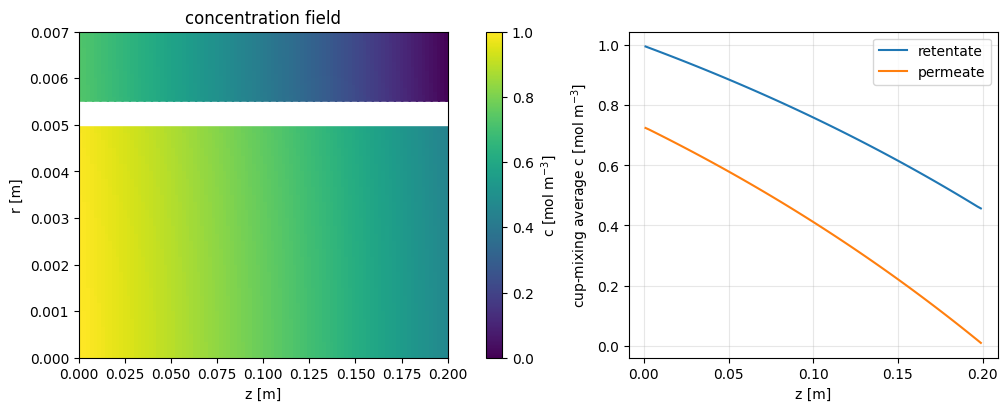

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
mesh_ret = ax[0].pcolormesh(model.z_f, model.r_f_ret, c_ret.T, shading="flat", vmin=0.0, vmax=cfg.c_ret_in)
mesh_perm = ax[0].pcolormesh(model.z_f, model.r_f_perm, c_perm.T, shading="flat", vmin=0.0, vmax=cfg.c_ret_in)
ax[0].axhline(cfg.radius_ret, color="white", lw=1.0)
ax[0].axhline(cfg.radius_perm, color="white", lw=1.0, ls="--")
ax[0].set_xlabel("z [m]")
ax[0].set_ylabel("r [m]")
ax[0].set_title("concentration field")
fig.colorbar(mesh_perm, ax=ax[0], label="c [mol m$^{-3}$]")

ax[1].plot(model.z_c, summary["c_ret_avg"], label="retentate")
ax[1].plot(model.z_c, summary["c_perm_avg"], label="permeate")
ax[1].set_xlabel("z [m]")
ax[1].set_ylabel("cup-mixing average c [mol m$^{-3}$]")
ax[1].legend()
ax[1].grid(True, alpha=0.3)
plt.show()


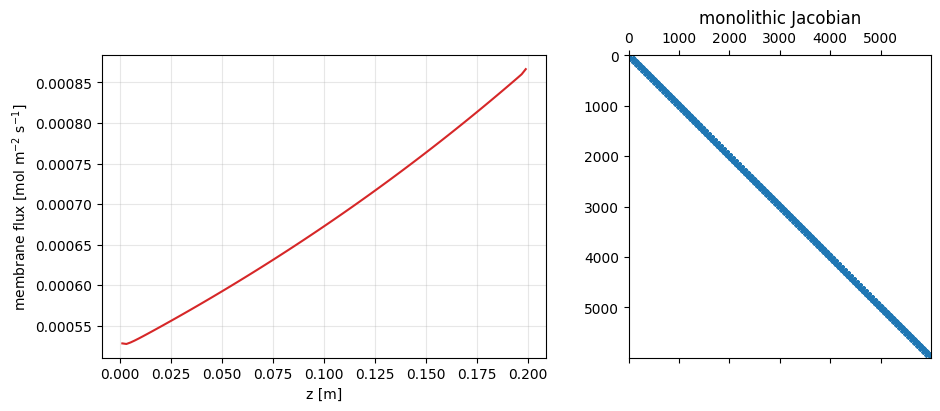

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
ax[0].plot(model.z_c, model.membrane_flux(c_all).ravel(), color="tab:red")
ax[0].set_xlabel("z [m]")
ax[0].set_ylabel("membrane flux [mol m$^{-2}$ s$^{-1}$]")
ax[0].grid(True, alpha=0.3)

ax[1].spy(jac, markersize=0.4)
ax[1].set_title("monolithic Jacobian")
plt.show()


## Validation

The membrane only transfers material between the two domains, so the sum of retentate and permeate outlet molar flows should match the inlet molar flow. The solution should also remain non-negative and move material from the retentate into the initially clean permeate stream.

In [7]:
{
        "mass-balance error": summary["mass_balance_error"],
        "retentate depleted": bool(summary["c_ret_avg"][-1] < cfg.c_ret_in),
        "permeate enriched": bool(summary["c_perm_avg"][0] > cfg.c_perm_in),
        "membrane flux retentate to permeate": bool(np.all(model.membrane_flux(c_all) >= -1.0e-12)),
        "nonnegative concentrations": bool(np.all(c_all >= -1.0e-12)),
}


{'mass-balance error': np.float64(1.2844647303680583e-12),
 'retentate depleted': True,
 'permeate enriched': True,
 'membrane flux retentate to permeate': True,
 'nonnegative concentrations': True}

## Discussion

The retentate and permeate operators are assembled independently, then embedded into a shared state vector. The interface matrices express the membrane boundary values in terms of neighboring cell-center values, which gives one monolithic sparse solve.